# JATENZO Dose Recommender - CatBoost model

**What this does, in plain terms:** given a patient (age, BMI, current testosterone, current dose) and a *target* testosterone, this model predicts the testosterone the patient would reach at **each** candidate dose, then recommends the dose that gets closest to the target.

This notebook uses the **CatBoost** engine. The XGBoost, LightGBM, and CatBoost notebooks are identical except for the engine, so you can compare them fairly.

Run the cells top to bottom. Each section starts with a short explanation.

## Setup

In [1]:
# --- Setup (run this first) -------------------------------------------------
import os, sys, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

ENGINE = "catboost"          # the model engine this notebook uses

# find the project folder and load the pipeline pieces
REPO = os.getcwd()
while not os.path.isdir(os.path.join(REPO, "src")) and REPO != os.path.dirname(REPO):
    REPO = os.path.dirname(REPO)
sys.path.insert(0, os.path.join(REPO, "src"))

from data import build_abt
from models import OutcomeTModel
from guardrails import directional_dose

print("Ready. Using engine:", ENGINE)


Ready. Using engine: catboost


## Step 1 - Load the data

Each row is one observation: a patient in some state was given a dose, and we recorded the testosterone they reached.

In [2]:
# Load the data. Uses your cleaned file (data/abt.csv) if present, else a built-in sample.
abt_path = os.path.join(REPO, "data", "abt.csv")
if os.path.exists(abt_path):
    df = build_abt({"source": "file", "abt_path": abt_path})
    print("Loaded cleaned data:", os.path.relpath(abt_path, REPO))
else:
    df = build_abt({"source": "synthetic"})
    print("No cleaned file found - using a built-in SAMPLE so the notebook runs.")

DOSES = sorted(df["new_dose"].unique().tolist())     # candidate doses seen in the data
print(f"{len(df):,} observations from {df['subject_id'].nunique()} patients")
print("Doses used in the trial (mg):", DOSES)
df.head()


Loaded cleaned data: data/abt.csv
953 observations from 293 patients
Doses used in the trial (mg): [25, 50, 75, 100, 150, 200, 250, 300]


,subject_id,age,bmi,current_T,current_dose,new_dose,outcome_T,delta_t,delta_t_win,interval_days,is_switch,pair
0,101-010,54,34.436981,264.0,50,75,313.0,49.0,49.0,30,1,P1: 30-60
1,101-015,68,35.381404,216.0,50,75,387.0,171.0,171.0,30,1,P1: 30-60
2,101-018,48,31.496063,1550.0,200,100,121.0,-1429.0,-953.4,30,1,P1: 30-60
3,101-025,40,25.013487,1480.0,200,100,292.0,-1188.0,-953.4,30,1,P1: 30-60
4,101-031,42,23.977599,296.0,50,75,568.0,272.0,272.0,30,1,P1: 30-60


## Step 2 - Train the model

We hold out a fifth of the **patients** entirely, so the model is tested on people it has never seen.

In [3]:
# Split by PATIENT (never split a patient across train/test) and train the model.
from sklearn.model_selection import GroupShuffleSplit
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
              .split(df, groups=df["subject_id"]))
train, test = df.iloc[tr], df.iloc[te]

model = OutcomeTModel({"engine": ENGINE,
                       "hyperparameters": {"n_estimators": 400,
                                           "learning_rate": 0.05, "max_depth": 3}})
model.fit(train, train["outcome_T"])
print(f"Trained on {len(train)} rows; testing on {len(test)} held-out patients' rows.")


Trained on 772 rows; testing on 181 held-out patients' rows.


## Step 3 - How good is it?

Two fair tests: how accurately it predicts the final testosterone, and how often its dose recommendation matches what actually happened.

In [4]:
# TEST 1 - how well does it predict the final testosterone the patient actually reached?
pred = model.predict(test)
actual = test["outcome_T"].values
rmse = float(np.sqrt(np.mean((actual - pred) ** 2)))
r2   = float(1 - np.sum((actual - pred)**2) / np.sum((actual - actual.mean())**2))

# TEST 2 - if a patient wanted the T they actually achieved, would we recommend the
#          dose they actually took? Focus on rows where the dose was CHANGED - those are
#          the real decisions. (On unchanged-dose rows the answer is trivially "keep it".)
idx = {d: i for i, d in enumerate(DOSES)}
rec = model.recommend(test, actual)
taken = test["new_dose"].values
switch = test["is_switch"].values == 1
def within1(mask):
    a, b = rec[mask], taken[mask]
    return float(np.mean([abs(idx[x]-idx[y]) <= 1 for x, y in zip(a, b)])) if mask.sum() else float("nan")

print("HOW WELL IT PREDICTS FINAL TESTOSTERONE")
print(f"   Typical miss (RMSE): {rmse:,.0f} ng/dL   |   Explains {r2*100:.0f}% of the variation")
print()
print("DOSE RECOMMENDATION - within one step of what actually happened")
print(f"   On DOSE-CHANGE decisions (what matters): {within1(switch)*100:.0f}%")
print(f"   On all rows:                             {within1(np.ones(len(rec),bool))*100:.0f}%")
print(f"   Rows where the dose was actually changed: {int(switch.sum())} of {len(test)}")


HOW WELL IT PREDICTS FINAL TESTOSTERONE
   Typical miss (RMSE): 468 ng/dL   |   Explains 13% of the variation

DOSE RECOMMENDATION - within one step of what actually happened
   On DOSE-CHANGE decisions (what matters): 58%
   On all rows:                             48%
   Rows where the dose was actually changed: 26 of 181


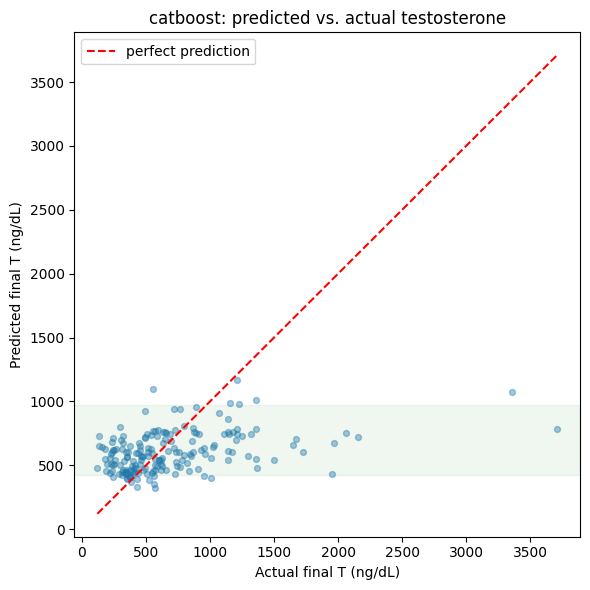

In [5]:
# Picture: predicted vs. actual final testosterone. Closer to the diagonal line = better.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(actual, pred, alpha=0.4, s=18)
lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="perfect prediction")
ax.axhspan(425, 970, color="green", alpha=0.06)
ax.set_xlabel("Actual final T (ng/dL)"); ax.set_ylabel("Predicted final T (ng/dL)")
ax.set_title(f"{ENGINE}: predicted vs. actual testosterone")
ax.legend(); plt.tight_layout(); plt.show()


## Step 4 - Recommend a dose for a patient

This is the actual product: try every dose, predict the outcome, pick the closest to the goal.

Patient: age 68, BMI 35.4, current T 216.0, on 50 mg. Goal: 500 ng/dL.


,dose_mg,predicted_final_T,distance_to_goal
0,25,381,119
1,50,368,132
2,75,367,133
3,100,379,121
4,150,560,60
5,200,561,61
6,250,630,130
7,300,927,427


--> Model's pick (closest to goal): 150 mg


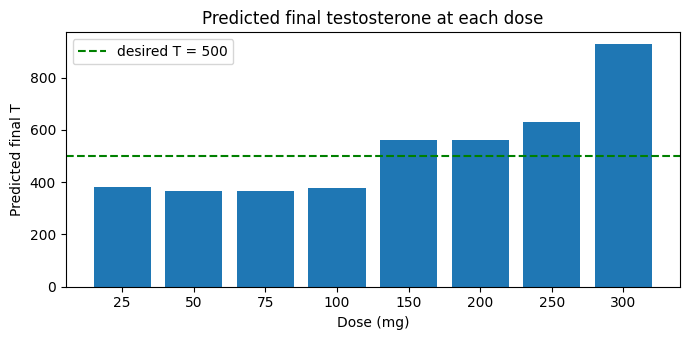

In [6]:
# Recommend a dose for one example patient (taken from the real held-out data).
# The model tries every dose, predicts the resulting T for each, and picks the one
# closest to the patient's desired testosterone.
row = test.iloc[0]
patient = {"age": int(row["age"]), "bmi": round(float(row["bmi"]), 1),
           "current_T": float(row["current_T"]), "current_dose": int(row["current_dose"])}
desired_T = 500      # where we want this patient to land (ng/dL) - a healthy mid-range

table = pd.DataFrame([{"dose_mg": d,
                       "predicted_final_T":
                           round(float(model.predict(pd.DataFrame([{**patient, "new_dose": d}]))[0]))}
                      for d in DOSES])
table["distance_to_goal"] = (table["predicted_final_T"] - desired_T).abs()
best = int(table.sort_values("distance_to_goal").iloc[0]["dose_mg"])

print(f"Patient: age {patient['age']}, BMI {patient['bmi']}, "
      f"current T {patient['current_T']}, on {patient['current_dose']} mg. Goal: {desired_T} ng/dL.")
display(table)
print(f"--> Model's pick (closest to goal): {best} mg")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(table["dose_mg"].astype(str), table["predicted_final_T"])
ax.axhline(desired_T, color="green", linestyle="--", label=f"desired T = {desired_T}")
ax.set_xlabel("Dose (mg)"); ax.set_ylabel("Predicted final T"); ax.legend()
ax.set_title("Predicted final testosterone at each dose"); plt.tight_layout(); plt.show()


## Step 5 - Guardrails

The guardrails are a plain-English safety net applied **after** the model, so the recommendation always moves in the sensible direction:

1. **New patient** -> start at the standard starting dose.
2. **Keep T the same** -> keep the current dose.
3. **Want higher T** -> the dose must go up.
4. **Want lower T** -> the dose must go down.

They never invent a dose - they only correct the direction of the model's suggestion.

In [7]:
# Guardrails: a simple safety layer that makes the recommendation's DIRECTION sensible.
# It runs AFTER the model and only corrects the direction - it never invents a dose.
START = DOSES[len(DOSES)//2]     # a representative starting dose for a new patient
def show(label, proposed, cur_dose, cur_T, want_T):
    d = directional_dose(proposed, cur_dose, cur_T, want_T, ladder=DOSES, start_dose=START)
    print(f"{label:38s} -> {d.dose:>3} mg   ({d.rationale})")

print("THE FOUR GUARDRAILS (doses from this trial:", DOSES, ")\n")
show("1. New patient (no dose yet)",        200, 0,   300, 600)
show("2. Want to KEEP T the same",          200, 150, 600, 610)
show("3. Want HIGHER T (force step up)",     50, 150, 400, 900)
show("4. Want LOWER T (force step down)",   300, 200, 900, 400)


THE FOUR GUARDRAILS (doses from this trial: [25, 50, 75, 100, 150, 200, 250, 300] )

1. New patient (no dose yet)           -> 150 mg   (Treatment-naive: standard start dose.)
2. Want to KEEP T the same             -> 150 mg   (Goal is to maintain T: keep current dose.)
3. Want HIGHER T (force step up)       -> 200 mg   (Goal is higher T: dose stepped up.)
4. Want LOWER T (force step down)      -> 150 mg   (Goal is lower T: dose stepped down.)


## Summary

The **CatBoost** model predicts final testosterone at each dose and recommends the one closest to the target, with guardrails keeping the direction sensible. Swap this notebook for the XGBoost / LightGBM / CatBoost version to compare engines on the same data.

*Numbers here use a built-in sample until the real cleaned data (`data/abt.csv`) is added - then re-run and the numbers update.*